# Exploratory Data Analysis of Chordonomicon

This notebook treats the seven CSV shards in `data/` as **one dataset**: Chordonomicon v2, a corpus of user-generated chord progressions with Spotify-linked metadata ([Kantarelis et al., 2024](https://arxiv.org/abs/2410.22046)).

The project goal is a **genre predictor**. The EDA therefore spends most of its attention on:

- how complete and consistent the genre labels are
- how artists, decades, and chord sequences relate to those labels
- what that implies for train/test design later

We do **not** train a model here. Derived columns stay in this session; the CSV files are never modified.

**Contents**

1. Context and goal
2. Load shards as a single table
3. Schema, sample, and dtypes
4. Data quality
5. Metadata coverage (usable supervised subset)
6. Genre analysis
7. Time (decade vs release date)
8. Chord sequences and song structure
9. Harmonic vocabulary and genre relationships
10. Implications for the genre predictor


## 1. Context and goal

Chordonomicon was scraped from Ultimate Guitar, then matched to Spotify for release dates and **artist-level** genres. Each row is one track:

| Column | Role |
| --- | --- |
| `id` | Unique track identifier |
| `chords` | Symbolic progression, optionally tagged with parts (`<verse_1>`, `<chorus_2>`, …) |
| `release_date`, `decade` | Temporal metadata |
| `genres` | Raw Spotify artist tags (multi-label, quoted strings) |
| `main_genre` | One of 12 coarse labels mapped from those tags (the classification target) |
| `rock_genre` | Fine-grained rock-family subgenre (179 classes) |
| `artist_id`, `spotify_artist_id`, `spotify_song_id` | Identity / linkage |

The files `chordonomicon_v2_part_*.csv` are a **storage split** (100k rows per chunk from `data/split_csv.py`), not a train/validation split and not a domain partition. Analysis below concatenates them before any statistic is computed.


## Setup

Plot titles state the question being asked. Comments next to code say **what relationship** is being measured.


In [1]:
%matplotlib inline

from __future__ import annotations

import re
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.figsize": (11, 5),
        "axes.titlesize": 13,
        "axes.titleweight": "medium",
        "figure.dpi": 110,
    }
)
pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 140)

# Resolve data dir whether the kernel cwd is the repo root or notebooks/.
if (Path("data") / "chordonomicon_v2_part_0.csv").exists():
    DATA_DIR = Path("data")
elif (Path("..") / "data" / "chordonomicon_v2_part_0.csv").exists():
    DATA_DIR = Path("..") / "data"
else:
    raise FileNotFoundError("Could not find data/chordonomicon_v2_part_*.csv")

print("DATA_DIR =", DATA_DIR.resolve())


DATA_DIR = /home/grivas/Escritorio/music_Chordonomicon_genre_predictor/data


## 2. Load shards as a single dataset

We glob every `chordonomicon_v2_part_*.csv`, check that headers match, and concatenate. Row counts per file should be 100,000 for parts 0–5 and 79,807 for part 6 (679,807 total, matching the published corpus size).


In [2]:
files = sorted(DATA_DIR.glob("chordonomicon_v2_part_*.csv"))
assert files, f"No CSV shards found in {DATA_DIR}"

headers = []
file_rows = []
frames = []
for path in files:
    part = pd.read_csv(path, low_memory=False)
    headers.append(tuple(part.columns))
    file_rows.append({"file": path.name, "n_rows": len(part), "n_cols": part.shape[1]})
    frames.append(part)

header_set = set(headers)
print("Unique header signatures:", len(header_set))
assert len(header_set) == 1, f"Shards do not share a schema: {header_set}"

df = pd.concat(frames, ignore_index=True)
del frames  # drop the list of copies; `df` is the analysis table from here on

file_counts = pd.DataFrame(file_rows)
display(file_counts)
print(f"Concatenated shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("Columns:", list(df.columns))
assert df.shape[0] == file_counts["n_rows"].sum()


Unique header signatures: 1


,file,n_rows,n_cols
0,chordonomicon_v2_part_0.csv,100000,10
1,chordonomicon_v2_part_1.csv,100000,10
2,chordonomicon_v2_part_2.csv,100000,10
3,chordonomicon_v2_part_3.csv,100000,10
4,chordonomicon_v2_part_4.csv,100000,10
5,chordonomicon_v2_part_5.csv,100000,10
6,chordonomicon_v2_part_6.csv,79807,10


Concatenated shape: 679,807 rows × 10 columns
Columns: ['id', 'chords', 'release_date', 'genres', 'decade', 'rock_genre', 'artist_id', 'main_genre', 'spotify_song_id', 'spotify_artist_id']


**What we observed.** All seven shards share the same 10-column schema, so concatenation does not invent missing fields or misaligned types. The last shard is a remainder chunk, not a different population. From this point every plot and table is computed on the **full 679,807-track table**.


## 3. Schema, sample, and dtypes

`chords` is a long space-separated string. `genres` stores several Spotify tags as separately quoted tokens (`'nu metal' 'post-grunge'`). Empty cells were read as NaN. `decade` arrives as a float-like string (`2010.0`) and will be parsed as a nullable integer. `release_date` mixes `YYYY-MM-DD`, `YYYY-MM`, and `YYYY`.


In [3]:
print("dtypes after concat:")
display(df.dtypes.to_frame("dtype"))

print("\nFirst three rows (chords truncated for display):")
preview = df.head(3).copy()
preview["chords"] = preview["chords"].str.slice(0, 160) + "…"
display(preview)

print("\nNon-null count / memory:")
df.info(memory_usage="deep")


dtypes after concat:


,dtype
id,int64
chords,str
release_date,str
genres,str
decade,float64
rock_genre,str
artist_id,str
main_genre,str
spotify_song_id,str
spotify_artist_id,str



First three rows (chords truncated for display):


,id,chords,release_date,genres,decade,rock_genre,artist_id,main_genre,spotify_song_id,spotify_artist_id
0,1,<intro_1> C <verse_1> F C E7 Amin C F C G7 C F C E7 Amin C F G7 C <verse_2> F C E7 Ami...,NaN,'classic country pop',NaN,NaN,artist_1,pop,NaN,4AIEGdwDzPELXYgM5JaEY5
1,2,<intro_1> E D A/Cs E D A/Cs <verse_1> E D A/Cs E D A/Cs E D A/Cs E D A C <chorus_1> E ...,2003-01-01,'alternative metal' 'alternative rock' 'nu metal' 'permanent wave' 'pop rock' 'post-gr...,2000.0,pop rock,artist_2,metal,2ffJZ2r8HxI5DHcmf3BO6c,694QW15WkebjcrWgQHzRYF
2,3,<intro_1> Csmin <verse_1> A Csmin A Csmin A Csmin A B <chorus_1> Csmin A Fsmin A B <ve...,2003-01-01,'alternative metal' 'canadian rock' 'funk metal' 'nu metal' 'post-grunge',2000.0,canadian rock,artist_3,metal,5KiY8SZEnvCPyIEkFGRR3y,0niJkG4tKkne3zwr7I8n9n



Non-null count / memory:


<class 'pandas.DataFrame'>
RangeIndex: 679807 entries, 0 to 679806
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 679807 non-null  int64  
 1   chords             679807 non-null  str    
 2   release_date       422181 non-null  str    
 3   genres             429753 non-null  str    
 4   decade             422181 non-null  float64
 5   rock_genre         145218 non-null  str    
 6   artist_id          510986 non-null  str    
 7   main_genre         352111 non-null  str    
 8   spotify_song_id    440284 non-null  str    
 9   spotify_artist_id  510986 non-null  str    
dtypes: float64(1), int64(1), str(8)
memory usage: 472.2 MB


In [4]:
# Parse temporal fields. decade is stored as 2010.0; release_year is the first four
# characters of release_date so we can later test whether decade == year // 10 * 10.
df["decade"] = pd.to_numeric(df["decade"], errors="coerce").astype("Int64")
df["release_year"] = pd.to_numeric(
    df["release_date"].astype("string").str.slice(0, 4), errors="coerce"
).astype("Int64")

# Presence flags used throughout quality / coverage sections.
presence = pd.DataFrame(
    {
        "main_genre": df["main_genre"].notna(),
        "genres": df["genres"].notna(),
        "rock_genre": df["rock_genre"].notna(),
        "release_date": df["release_date"].notna(),
        "decade": df["decade"].notna(),
        "artist_id": df["artist_id"].notna(),
        "spotify_artist_id": df["spotify_artist_id"].notna(),
        "spotify_song_id": df["spotify_song_id"].notna(),
        "chords": df["chords"].notna() & df["chords"].astype("string").str.len().gt(0),
    }
)

print("decade dtype:", df["decade"].dtype, "| unique decades:", df["decade"].dropna().nunique())
print("release_date formats among non-null dates:")
dates = df.loc[df["release_date"].notna(), "release_date"].astype("string")
fmt = pd.Series("other", index=dates.index)
fmt = fmt.mask(dates.str.fullmatch(r"\d{4}-\d{2}-\d{2}"), "YYYY-MM-DD")
fmt = fmt.mask(dates.str.fullmatch(r"\d{4}-\d{2}"), "YYYY-MM")
fmt = fmt.mask(dates.str.fullmatch(r"\d{4}"), "YYYY")
display(fmt.value_counts().rename("n").to_frame())


decade dtype: Int64 | unique decades: 14
release_date formats among non-null dates:


,n
YYYY-MM-DD,382936
YYYY,38284
YYYY-MM,961


**What we observed.** The table is track-level: one `id`, one chord string, optional metadata. Dates are mostly full ISO days, with a minority of year-only values — so time analysis should use **year/decade**, not calendar day. `main_genre` is already a coarse 12-way label; `genres` is the finer multi-label source it was derived from.


## 4. Data quality

This section asks four questions that affect a classifier:

1. Which fields are missing, and how often?
2. Are missing values independent, or do they arrive as **blocks** (e.g. no Spotify artist ⇒ no genre)?
3. Are `id`s unique, and are chord progressions unique?
4. Is `decade` a faithful encoding of `release_date`?


,n_missing,pct
rock_genre,534589,78.64
main_genre,327696,48.2
release_date,257626,37.9
decade,257626,37.9
genres,250054,36.78
spotify_song_id,239523,35.23
artist_id,168821,24.83
spotify_artist_id,168821,24.83
chords,0,0.0


findfont: Failed to find font weight medium, now using 400.


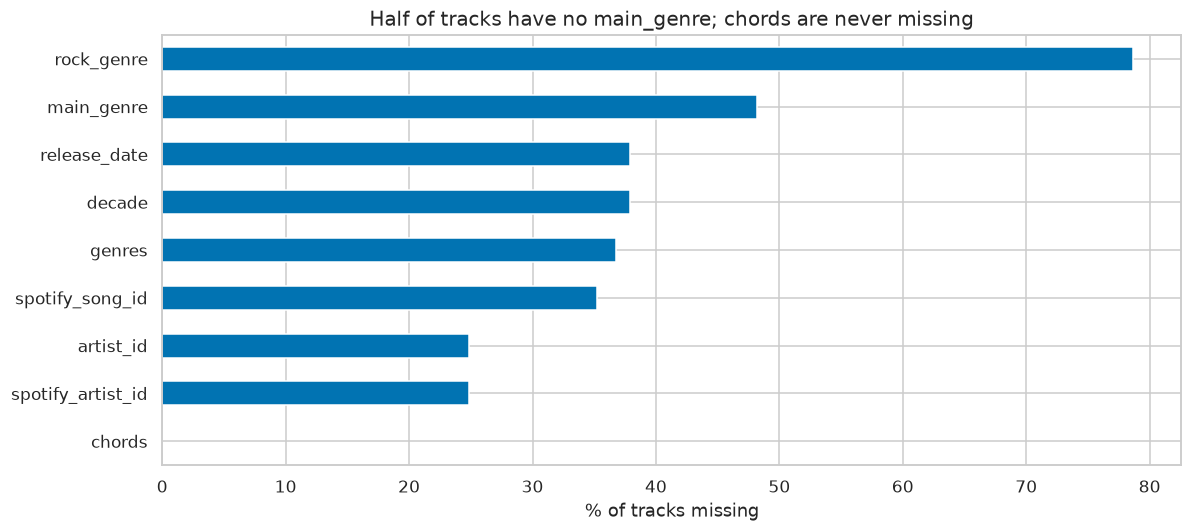

In [5]:
n = len(df)
missing = (~presence).sum().sort_values(ascending=False)
missing_tbl = pd.DataFrame(
    {"n_missing": missing, "pct": (100 * missing / n).round(2)}
)
display(missing_tbl)

ax = missing_tbl["pct"].plot(kind="barh", color=sns.color_palette("colorblind")[0])
ax.set_xlabel("% of tracks missing")
ax.set_title("Half of tracks have no main_genre; chords are never missing")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


artist_id missing XOR spotify_artist_id missing: 0
release_date missing XOR decade missing: 0
main_genre present but genres missing: 0
genres present but main_genre missing: 77642


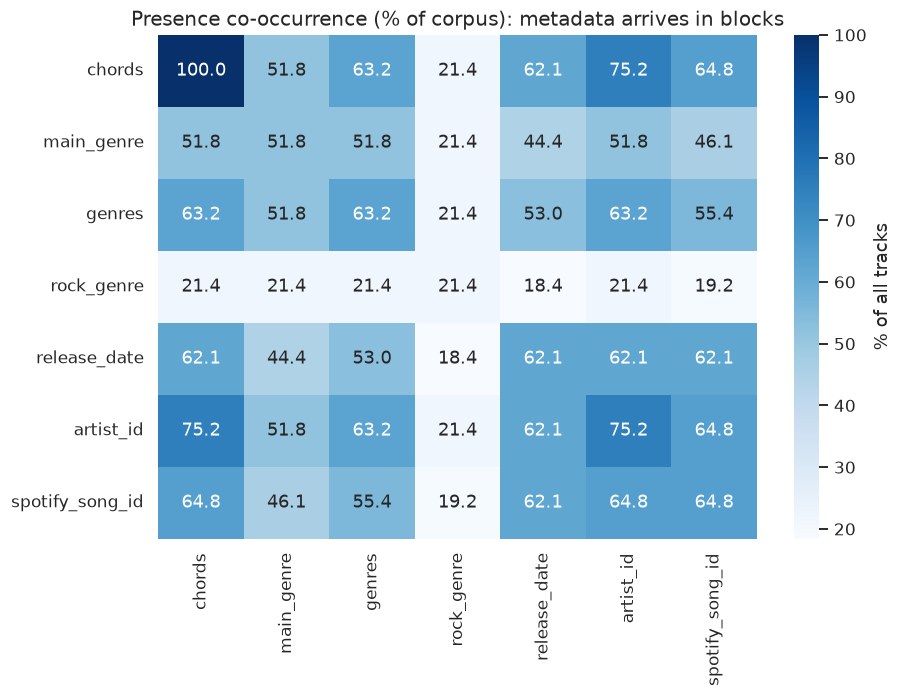

In [6]:
# Joint missingness: if two columns always go missing together, they likely share
# the same collection pipeline (Spotify match vs Ultimate Guitar scrape).
print("artist_id missing XOR spotify_artist_id missing:",
      int((presence["artist_id"] != presence["spotify_artist_id"]).sum()))
print("release_date missing XOR decade missing:",
      int((presence["release_date"] != presence["decade"]).sum()))
print("main_genre present but genres missing:",
      int((presence["main_genre"] & ~presence["genres"]).sum()))
print("genres present but main_genre missing:",
      int((presence["genres"] & ~presence["main_genre"]).sum()))

# Pairwise co-occurrence of *presence* (not missingness): diagonal = column support.
flags = presence[
    ["chords", "main_genre", "genres", "rock_genre", "release_date", "artist_id", "spotify_song_id"]
].astype(int)
cooc = flags.T @ flags
cooc_pct = (100 * cooc / n).round(1)

fig, ax = plt.subplots(figsize=(8.5, 6.5))
sns.heatmap(cooc_pct, annot=True, fmt=".1f", cmap="Blues", ax=ax, cbar_kws={"label": "% of all tracks"})
ax.set_title("Presence co-occurrence (% of corpus): metadata arrives in blocks")
plt.tight_layout()
plt.show()


In [7]:
print("Duplicate ids:", int(df["id"].duplicated().sum()))
print("id range:", int(df["id"].min()), "–", int(df["id"].max()), "| nunique:", df["id"].nunique())

# Identical chord strings (covers, alternate versions, or scrape collisions).
chord_vc = df["chords"].value_counts()
dup_groups = chord_vc[chord_vc > 1]
print(f"Unique chord strings: {df['chords'].nunique():,}")
print(f"Duplicate progression groups: {len(dup_groups):,} "
      f"({int(dup_groups.sum()):,} rows, max copies = {int(dup_groups.max())})")


Duplicate ids: 0
id range: 1 – 679807 | nunique: 679807


Unique chord strings: 677,199
Duplicate progression groups: 2,509 (5,117 rows, max copies = 6)


Tracks with both date and decade: 422,181
decade != 10*floor(year/10): 50,599 (12.0% of dated tracks)

Example mismatches:


,id,release_date,release_year,decade
14,15,2010-01-01,2010,2000
15,16,2000,2000,1990
27,28,2000-03-20,2000,1990
78,79,1980,1980,1970
100,101,2020-07-25,2020,2010
106,107,2010-10-06,2010,2000
124,125,2000-03-13,2000,1990
145,146,2020-10-16,2020,2010


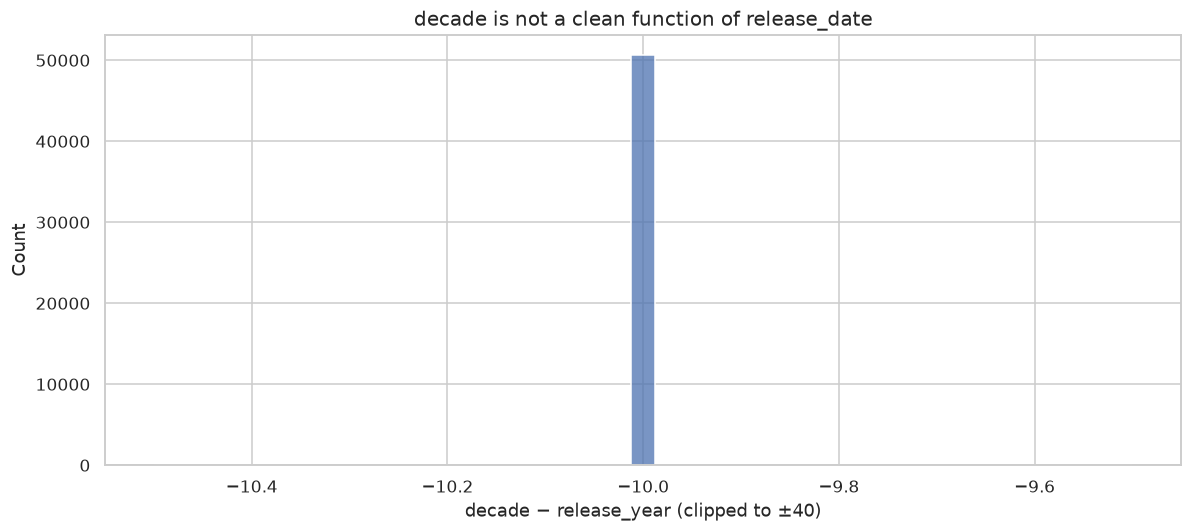

In [8]:
# Is decade just year floored to 10? If not, do not treat the two fields as interchangeable.
dated = df.dropna(subset=["release_year", "decade"])
expected = (dated["release_year"] // 10) * 10
mismatch = dated.loc[dated["decade"] != expected, ["id", "release_date", "release_year", "decade"]]
print(f"Tracks with both date and decade: {len(dated):,}")
print(f"decade != 10*floor(year/10): {len(mismatch):,} "
      f"({100 * len(mismatch) / len(dated):.1f}% of dated tracks)")

print("\nExample mismatches:")
display(mismatch.head(8))

delta = (mismatch["decade"] - mismatch["release_year"]).astype(int)
fig, ax = plt.subplots()
sns.histplot(delta.clip(-40, 40), bins=41, ax=ax)
ax.set_xlabel("decade − release_year (clipped to ±40)")
ax.set_title("decade is not a clean function of release_date")
plt.tight_layout()
plt.show()


**What we observed.**

- `chords` is complete; everything else is optional. The target `main_genre` is missing on about **48%** of rows, so a 12-way classifier can only train on the labeled half.
- Missingness is **block-structured**: `artist_id` and `spotify_artist_id` vanish together; `release_date` and `decade` vanish together. That is the Spotify join, not random holes.
- About 77k tracks have raw Spotify `genres` but **no** `main_genre` — tags that did not map onto the 12 Musicmap-inspired classes. They are unlabeled for the main task, not “other”.
- IDs are unique (1 … 679,807). A few thousand progressions are exact string duplicates (at most 6 copies). Harmless for EDA; worth a grouped split later if those rows share an artist.
- **Do not derive decade from `release_date` without checking.** Tens of thousands of dated tracks disagree. Possible causes include album vs track dates on Spotify, or decade assigned from a different field than the displayed `release_date`.


## 5. Metadata coverage — the usable supervised subset

A genre predictor needs a label. Optionally it also wants a date, an artist id (for grouped splits), and a Spotify track id. The combination of those flags is the real training universe, not the 679k headline count.


In [9]:
# Encode each track as a bit-string of coverage flags, then rank the common patterns.
combo_cols = ["main_genre", "genres", "release_date", "artist_id", "spotify_song_id"]
bit = presence[combo_cols].astype(int).astype(str).agg("".join, axis=1)
combo_counts = (
    bit.value_counts()
    .rename("n")
    .to_frame()
    .assign(pct=lambda x: (100 * x["n"] / n).round(2))
    .reset_index()
    .rename(columns={"index": "pattern"})
)
# pattern order: main_genre, genres, release_date, artist_id, spotify_song_id
legend = "pattern = " + "".join(f"{c[0]}" for c in combo_cols) + "  (" + ", ".join(combo_cols) + ")"
print(legend)
display(combo_counts.head(12))

labeled = presence["main_genre"].sum()
print(f"\nLabeled for 12-way main_genre: {labeled:,} ({100 * labeled / n:.1f}%)")
print(
    "Labeled AND has artist_id (needed for grouped splits):",
    f"{int((presence['main_genre'] & presence['artist_id']).sum()):,}",
)


pattern = mgras  (main_genre, genres, release_date, artist_id, spotify_song_id)


,pattern,n,pct
0,11111,301564,44.36
1,00000,168821,24.83
2,00111,61962,9.11
3,01111,58655,8.63
4,11010,38425,5.65
5,00010,17375,2.56
6,01010,14902,2.19
7,11011,12122,1.78
8,01011,4085,0.60
9,00011,1896,0.28



Labeled for 12-way main_genre: 352,111 (51.8%)
Labeled AND has artist_id (needed for grouped splits): 352,111


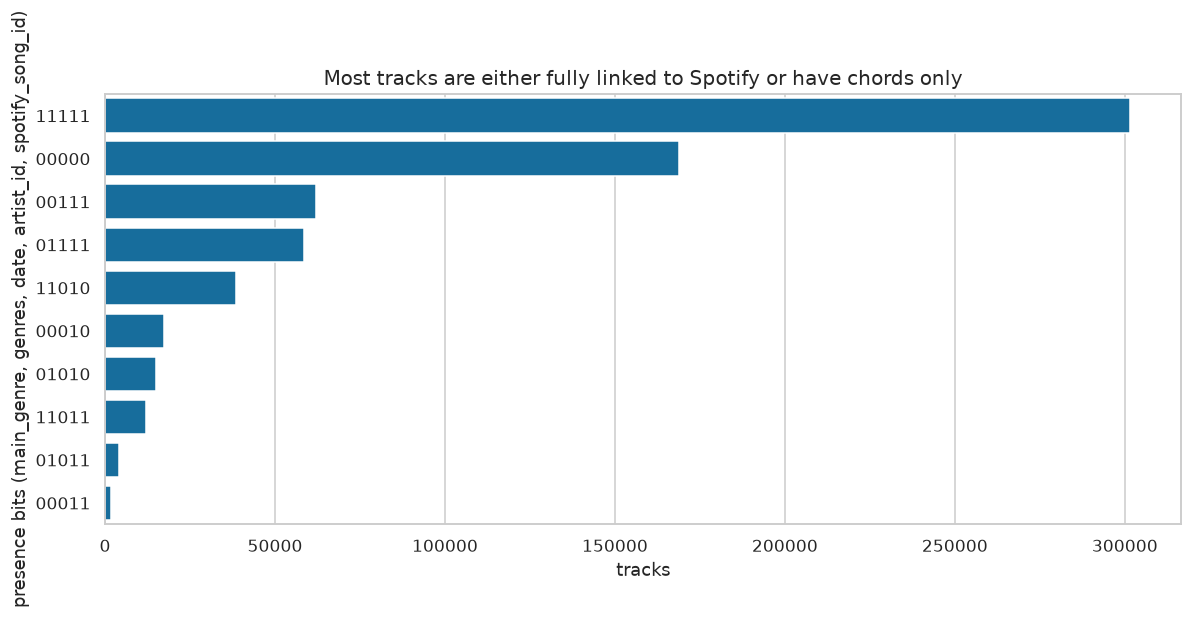

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
top = combo_counts.head(10)
sns.barplot(data=top, x="n", y="pattern", ax=ax, color=sns.color_palette("colorblind")[0])
ax.set_xlabel("tracks")
ax.set_ylabel("presence bits (main_genre, genres, date, artist_id, spotify_song_id)")
ax.set_title("Most tracks are either fully linked to Spotify or have chords only")
plt.tight_layout()
plt.show()


**What we observed.** Coverage is bimodal: a large block of tracks is fully Spotify-linked (label + date + ids), and another large block has **only chords**. The 12-way task lives in the first block (~352k rows). Modeling on the full 679k table would require a different objective (unsupervised / semi-supervised), because half the rows have no `main_genre`.


## 6. Genre analysis

`main_genre` is the 12-class target. `genres` is the multi-label Spotify source. `rock_genre` is a **rock-family** subgenre, not “a child of `main_genre == rock`”. Genre in this corpus is an **artist** attribute copied onto tracks — that is the leakage risk for random row splits.


,n,pct_labeled
main_genre,,
pop,85185,24.19
rock,67238,19.10
country,53306,15.14
alternative,47252,13.42
pop rock,39557,11.23
punk,16066,4.56
metal,11315,3.21
rap,11186,3.18
soul,7350,2.09


Majority-class baseline on labeled data: 'pop' at 24.2%


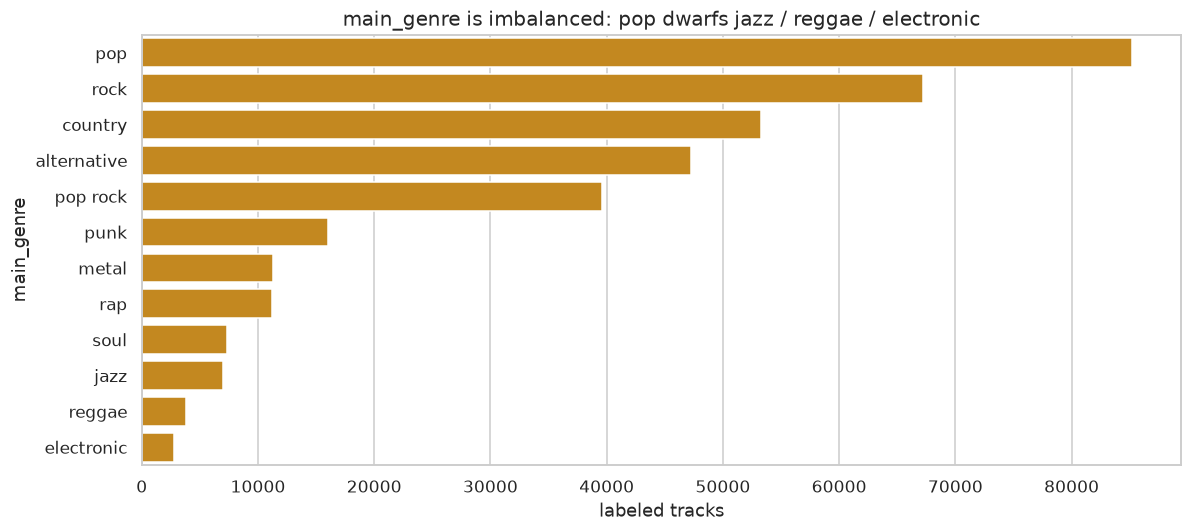

In [11]:
labeled_df = df.dropna(subset=["main_genre"])
genre_counts = labeled_df["main_genre"].value_counts()
majority_pct = 100 * genre_counts.iloc[0] / genre_counts.sum()

genre_tbl = genre_counts.rename("n").to_frame()
genre_tbl["pct_labeled"] = (100 * genre_tbl["n"] / genre_tbl["n"].sum()).round(2)
display(genre_tbl)
print(f"Majority-class baseline on labeled data: {genre_counts.index[0]!r} at {majority_pct:.1f}%")

fig, ax = plt.subplots()
sns.barplot(x=genre_counts.values, y=genre_counts.index, ax=ax, color=sns.color_palette("colorblind")[1])
ax.set_xlabel("labeled tracks")
ax.set_title("main_genre is imbalanced: pop dwarfs jazz / reggae / electronic")
plt.tight_layout()
plt.show()


Tracks with at least one Spotify genre tag: 429,753
Tags per tagged track — min/median/mean/max: 1 2.0 2.82 15


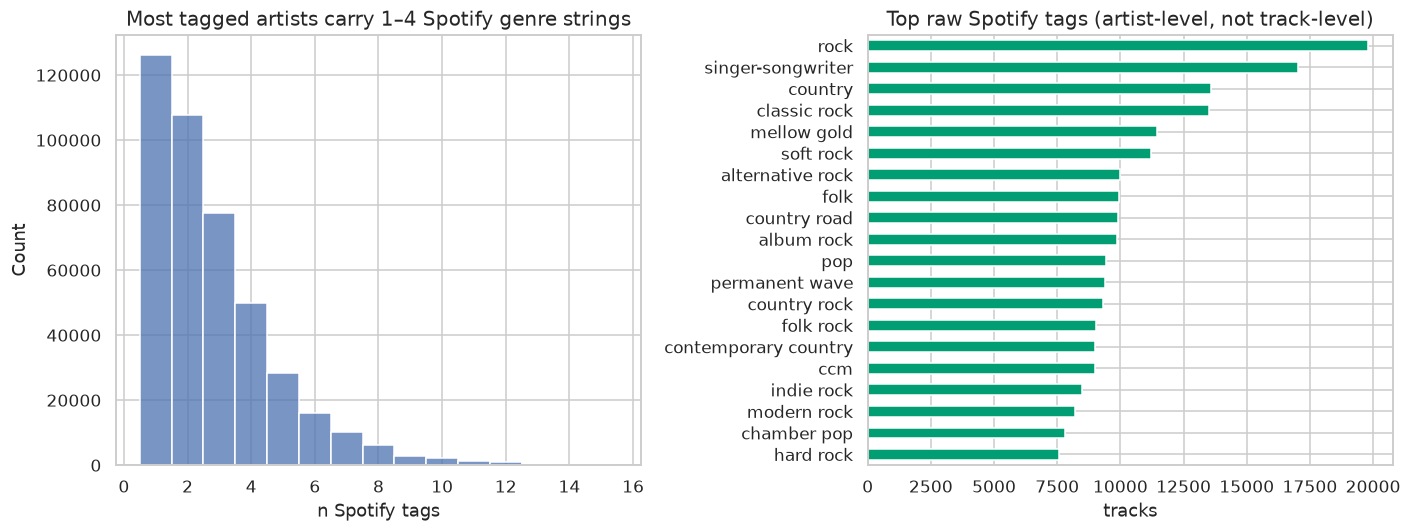

In [12]:
# Parse quoted Spotify tags: "'alternative metal' 'nu metal'" -> ['alternative metal', 'nu metal']
TAG_RE = re.compile(r"'([^']*)'")
tags = df["genres"].dropna().map(lambda s: TAG_RE.findall(str(s)))
n_tags = tags.map(len)

print("Tracks with at least one Spotify genre tag:", f"{len(tags):,}")
print("Tags per tagged track — min/median/mean/max:",
      int(n_tags.min()), float(n_tags.median()), round(n_tags.mean(), 2), int(n_tags.max()))

tag_counts = Counter(t for lst in tags for t in lst)
top_tags = pd.Series(dict(tag_counts.most_common(20)), name="n").sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(n_tags, bins=range(1, 17), ax=axes[0], discrete=True)
axes[0].set_title("Most tagged artists carry 1–4 Spotify genre strings")
axes[0].set_xlabel("n Spotify tags")
top_tags.plot(kind="barh", ax=axes[1], color=sns.color_palette("colorblind")[2])
axes[1].set_title("Top raw Spotify tags (artist-level, not track-level)")
axes[1].set_xlabel("tracks")
plt.tight_layout()
plt.show()


rock_genre,no rock_genre,has rock_genre,All
main_genre,,,
(no main_genre),327696,0,327696
alternative,33413,13839,47252
country,38223,15083,53306
electronic,2739,75,2814
jazz,4964,2037,7001
metal,6672,4643,11315
pop,85185,0,85185
pop rock,690,38867,39557
punk,12623,3443,16066


Unique rock_genre values: 179

Top 15 rock_genre labels:


,n
rock_genre,
christian alternative rock,5636
indie rock,4693
pop rock,4682
country rock,4095
modern country rock,3822
alternative rock,3744
modern rock,3739
heartland rock,3235
hard rock,3120


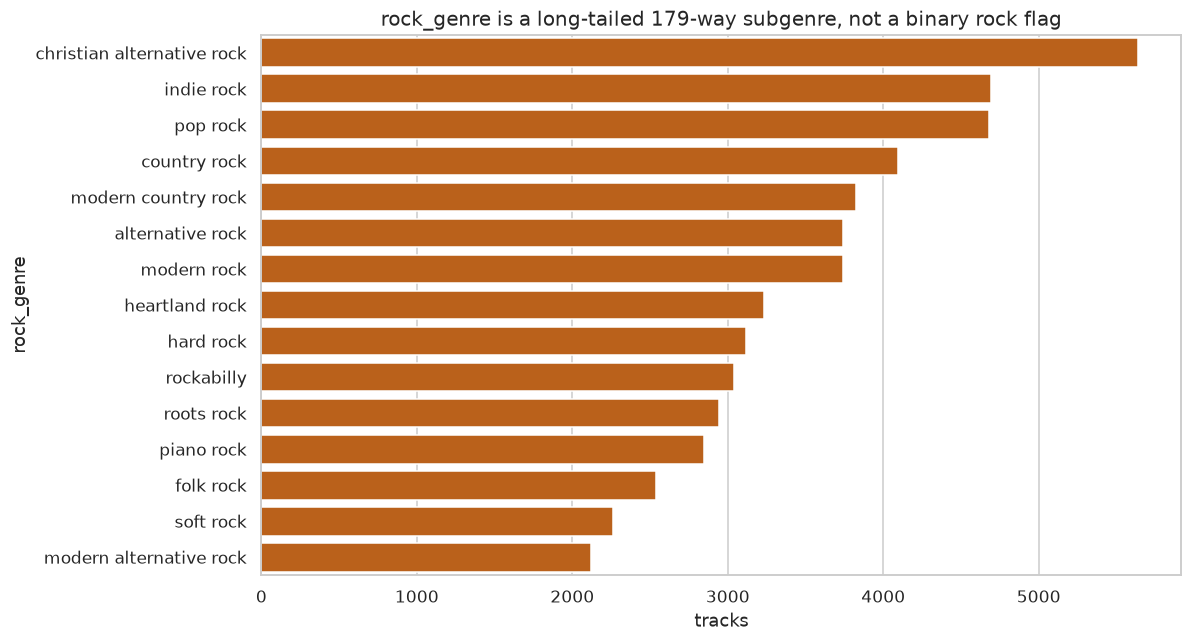

In [13]:
# rock_genre vs main_genre: the paper keeps the *least prevalent* rock-family tag.
# That tag can sit on a track whose coarse label is pop rock, country, alternative, …
has_rock = df["rock_genre"].notna()
ct = (
    pd.crosstab(
        df["main_genre"].fillna("(no main_genre)"),
        has_rock,
        margins=True,
    )
    .rename(columns={False: "no rock_genre", True: "has rock_genre"})
)
display(ct)

print("Unique rock_genre values:", df["rock_genre"].nunique(dropna=True))
print("\nTop 15 rock_genre labels:")
rock_top = df["rock_genre"].value_counts().head(15)
display(rock_top.to_frame("n"))

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(x=rock_top.values, y=rock_top.index, ax=ax, color=sns.color_palette("colorblind")[3])
ax.set_title("rock_genre is a long-tailed 179-way subgenre, not a binary rock flag")
ax.set_xlabel("tracks")
plt.tight_layout()
plt.show()


Artists with an id: 91,556
Tracks per artist — min/median/mean/max: 1 1.0 5.58 808
Artists with 1 track: 46254
Artists with ≥10 tracks: 11453
Artists with ≥50 tracks: 1561
Top 5 artist_id by catalog size:
 artist_id
artist_792     808
artist_355     708
artist_304     633
artist_723     544
artist_2930    492

Labeled artists: 38,057
Artists with more than one main_genre: 0 (0.00%)


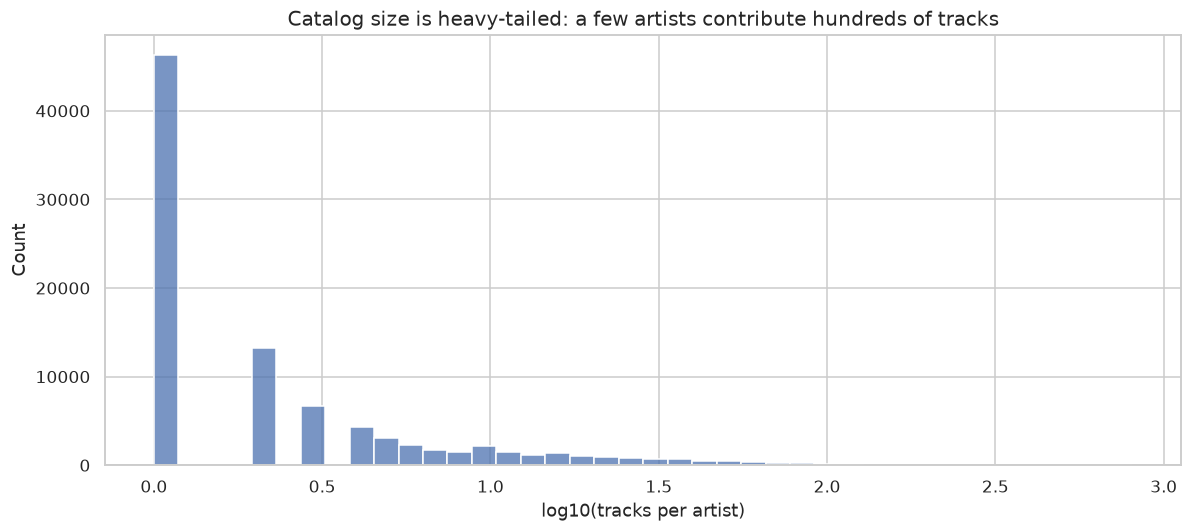

In [14]:
# Artist multiplicity: genre is copied from the artist, so many tracks share one label source.
artist_n = df.dropna(subset=["artist_id"]).groupby("artist_id").size()
print("Artists with an id:", f"{len(artist_n):,}")
print("Tracks per artist — min/median/mean/max:",
      int(artist_n.min()), float(artist_n.median()), round(artist_n.mean(), 2), int(artist_n.max()))
print("Artists with 1 track:", int((artist_n == 1).sum()))
print("Artists with ≥10 tracks:", int((artist_n >= 10).sum()))
print("Artists with ≥50 tracks:", int((artist_n >= 50).sum()))
print("Top 5 artist_id by catalog size:\n", artist_n.nlargest(5).to_string())

# Among labeled tracks, how often is main_genre constant inside an artist?
lab_art = labeled_df.dropna(subset=["artist_id"])
nunique_genre = lab_art.groupby("artist_id")["main_genre"].nunique()
print(f"\nLabeled artists: {len(nunique_genre):,}")
print("Artists with more than one main_genre:",
      f"{int((nunique_genre > 1).sum()):,} "
      f"({100 * (nunique_genre > 1).mean():.2f}%)")

fig, ax = plt.subplots()
sns.histplot(np.log10(artist_n), bins=40, ax=ax)
ax.set_xlabel("log10(tracks per artist)")
ax.set_title("Catalog size is heavy-tailed: a few artists contribute hundreds of tracks")
plt.tight_layout()
plt.show()


**What we observed.**

- **Class imbalance is severe.** Pop is roughly a quarter of the labeled set; electronic / reggae / jazz are a few thousand rows each. Accuracy without class weights or resampling will look like the majority baseline (~24%).
- Spotify `genres` is multi-label and **finer** than `main_genre`. A track can have tags and still lack a 12-way label when none of the tags map to the 12 buckets.
- `rock_genre` fires for rock, pop rock, country, alternative, metal, punk, … It is a parallel taxonomy, not a nested one. A rock-subgenre classifier should filter on `rock_genre.notna()`, not on `main_genre == "rock"`.
- **Artist leakage:** `main_genre` is almost constant within `artist_id` (as expected for artist-level Spotify genres). A random shuffle of rows puts the same artist — and therefore the same label — in train and test. Later modeling should split **by `artist_id`**.


## 7. Time: decade, release year, and genre mix

The corpus is contemporary popular music scraped from a guitar-tab site, so we expect a strong 2000s–2010s mass and almost nothing before 1950. Genre mix over time matters if a model confuses “sounds like 2010 pop” with “is pop”.


,n
decade,
1890,28
1900,5
1910,2
1920,49
1930,83
1940,148
1950,1748
1960,9488
1970,16110


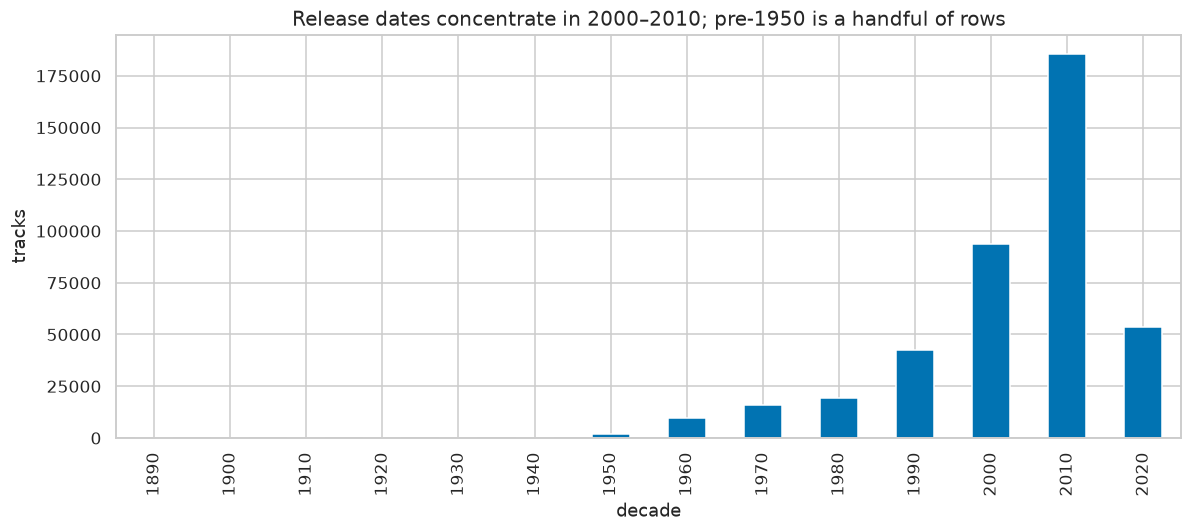

In [15]:
decade_counts = df["decade"].value_counts().sort_index()
display(decade_counts.rename("n").to_frame())

fig, ax = plt.subplots()
decade_counts.plot(kind="bar", ax=ax, color=sns.color_palette("colorblind")[0])
ax.set_xlabel("decade")
ax.set_ylabel("tracks")
ax.set_title("Release dates concentrate in 2000–2010; pre-1950 is a handful of rows")
plt.tight_layout()
plt.show()


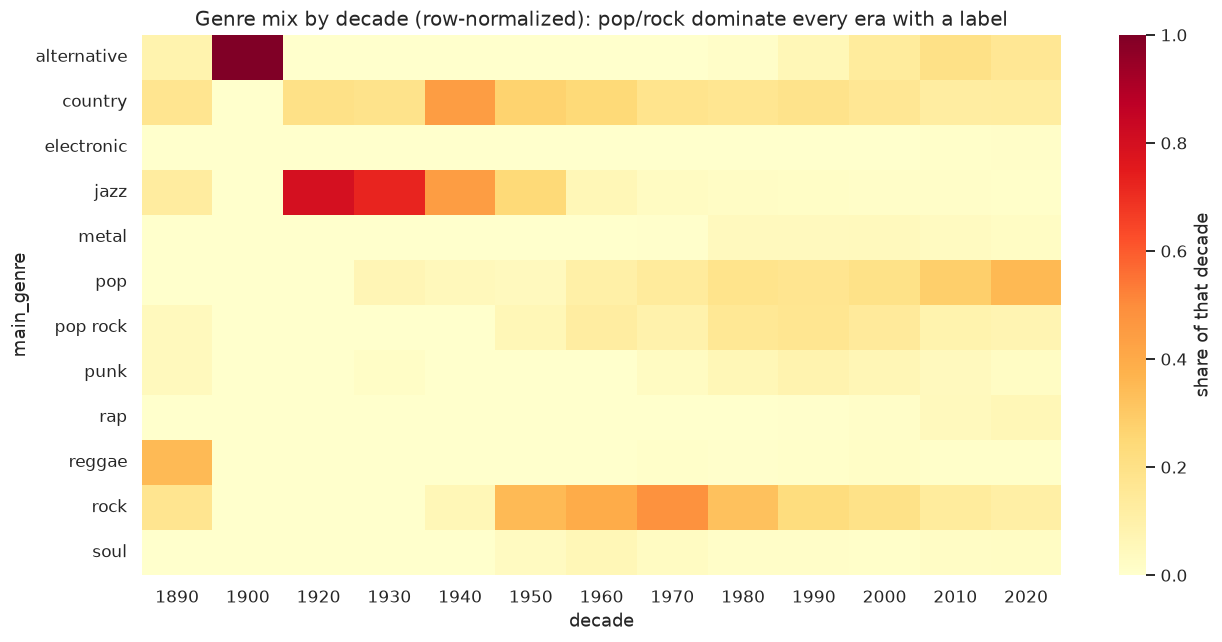

Labeled tracks per decade (volume behind the mix):


,n_labeled
decade,
1890,23
1900,1
1920,40
1930,58
1940,83
1950,1296
1960,7916
1970,13808
1980,16491


In [16]:
# Row-normalized: each decade's labeled tracks sum to 1, so we see mix, not volume.
mix = (
    labeled_df.dropna(subset=["decade"])
    .pivot_table(index="decade", columns="main_genre", values="id", aggfunc="count", fill_value=0)
)
mix_share = mix.div(mix.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(mix_share.T, cmap="YlOrRd", ax=ax, cbar_kws={"label": "share of that decade"})
ax.set_title("Genre mix by decade (row-normalized): pop/rock dominate every era with a label")
ax.set_xlabel("decade")
plt.tight_layout()
plt.show()

print("Labeled tracks per decade (volume behind the mix):")
display(mix.sum(axis=1).astype(int).rename("n_labeled").to_frame())


**What we observed.** Decade is heavily skewed to **2010**, then 2000 and 2020. Pre-1960 cells are too small to estimate a genre distribution. Within decades that have mass, pop / rock / country / alternative remain the bulk — there is no decade where jazz or electronic becomes the mode. A model that uses decade as a feature will mostly learn “this corpus is recent pop/rock”, not a clean period style.


## 8. Chord sequences and song structure

`chords` mixes two token types:

- **Chord symbols** such as `C`, `Amin`, `E7`, `A/Cs` (slash = inversion / specified bass)
- **Part tags** such as `<verse_1>`, `<chorus_2>` — eight families in the paper: intro, verse, chorus, bridge, interlude, solo, instrumental, outro

We parse in one pass over 679k strings and **do not explode** ~52 million chord tokens into a DataFrame. Per-track features (`n_chords`, unique vocabulary, part counts) stay at track grain. Global histograms use `Counter`s.


In [17]:
PART_RE = re.compile(r"^<([A-Za-z]+)_(\d+)>$")
CANON_PARTS = ["intro", "verse", "chorus", "bridge", "interlude", "solo", "instrumental", "outro"]


def split_tokens(chords: str) -> tuple[list[str], list[str]]:
    # Return (chord_tokens, part_names_lower) for one track.
    chord_toks: list[str] = []
    parts: list[str] = []
    for tok in str(chords).split():
        m = PART_RE.match(tok)
        if m:
            parts.append(m.group(1).lower())
        else:
            chord_toks.append(tok)
    return chord_toks, parts


n_rows = len(df)
n_chords = np.zeros(n_rows, dtype=np.int32)
n_unique = np.zeros(n_rows, dtype=np.int32)
n_parts = np.zeros(n_rows, dtype=np.int32)
has_structure = np.zeros(n_rows, dtype=bool)

global_chords: Counter[str] = Counter()
global_parts: Counter[str] = Counter()
unknown_parts: Counter[str] = Counter()

chord_col = df["chords"].to_numpy()
for i, raw in enumerate(tqdm(chord_col, desc="Parsing chord sequences")):
    ctoks, parts = split_tokens(raw)
    n_chords[i] = len(ctoks)
    n_unique[i] = len(set(ctoks))
    n_parts[i] = len(parts)
    has_structure[i] = bool(parts)
    global_chords.update(ctoks)
    for p in parts:
        if p in CANON_PARTS:
            global_parts[p] += 1
        else:
            unknown_parts[p] += 1

df["n_chords"] = n_chords
df["n_unique_chords"] = n_unique
df["n_parts"] = n_parts
df["has_structure"] = has_structure

print("Tracks with at least one part tag:", f"{int(has_structure.sum()):,} "
      f"({100 * has_structure.mean():.1f}%)")
print("Unknown part names (should be near zero):", dict(unknown_parts))
print("\nChord-length summary (tokens, excluding part tags):")
display(pd.Series(n_chords, name="n_chords").describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_frame())
print("Total chord tokens:", f"{int(n_chords.sum()):,}")
print("Unique chord spellings:", f"{len(global_chords):,}")


Parsing chord sequences:   0%|          | 0/679807 [00:00<?, ?it/s]

Tracks with at least one part tag: 397,580 (58.5%)
Unknown part names (should be near zero): {}

Chord-length summary (tokens, excluding part tags):


,n_chords
count,679807.000000
mean,76.484408
std,54.593484
min,1.000000
5%,21.000000
25%,47.000000
50%,71.000000
75%,97.000000
95%,145.000000
max,2549.000000


Total chord tokens: 51,994,636
Unique chord spellings: 4,316


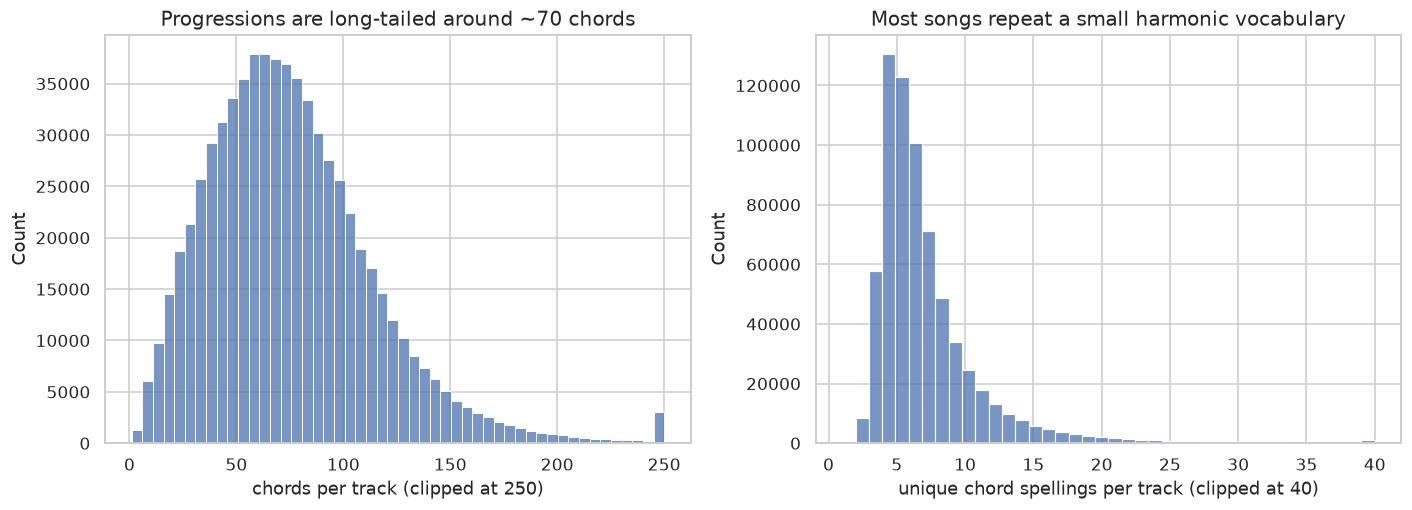

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.histplot(np.clip(df["n_chords"], 0, 250), bins=50, ax=axes[0])
axes[0].set_xlabel("chords per track (clipped at 250)")
axes[0].set_title("Progressions are long-tailed around ~70 chords")
sns.histplot(np.clip(df["n_unique_chords"], 0, 40), bins=40, ax=axes[1])
axes[1].set_xlabel("unique chord spellings per track (clipped at 40)")
axes[1].set_title("Most songs repeat a small harmonic vocabulary")
plt.tight_layout()
plt.show()


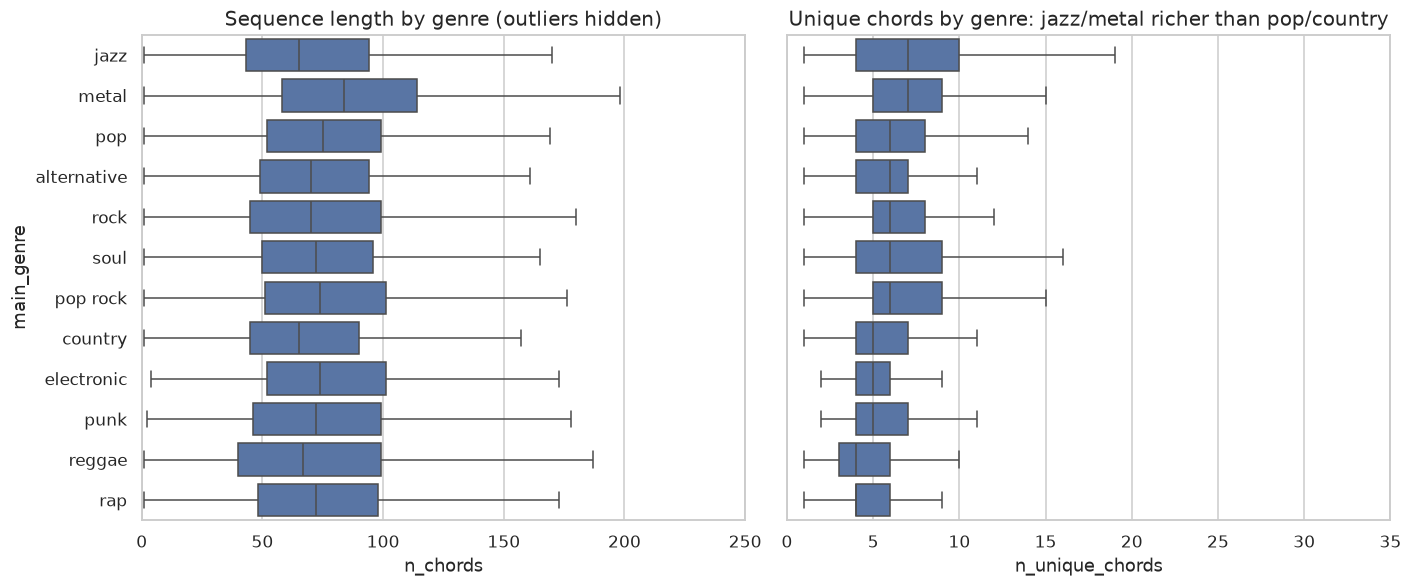

Median n_chords / n_unique by main_genre:


,n_chords,n_unique_chords
main_genre,,
jazz,65.0,7.0
metal,84.0,7.0
pop,75.0,6.0
alternative,70.0,6.0
rock,70.0,6.0
soul,72.0,6.0
pop rock,74.0,6.0
country,65.0,5.0
electronic,74.0,5.0


In [19]:
# Length and vocabulary by target class — harmonic “richness” as a cheap genre cue.
lab = df.dropna(subset=["main_genre"])
order = lab.groupby("main_genre")["n_unique_chords"].median().sort_values(ascending=False).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
sns.boxplot(data=lab, y="main_genre", x="n_chords", order=order, showfliers=False, ax=axes[0])
axes[0].set_xlim(0, 250)
axes[0].set_title("Sequence length by genre (outliers hidden)")
sns.boxplot(data=lab, y="main_genre", x="n_unique_chords", order=order, showfliers=False, ax=axes[1])
axes[1].set_xlim(0, 35)
axes[1].set_title("Unique chords by genre: jazz/metal richer than pop/country")
plt.tight_layout()
plt.show()

print("Median n_chords / n_unique by main_genre:")
display(
    lab.groupby("main_genre")[["n_chords", "n_unique_chords"]]
    .median()
    .reindex(order)
)


,n_tags
intro,270253
verse,961399
chorus,897752
bridge,186719
interlude,75528
solo,37882
instrumental,76688
outro,164234


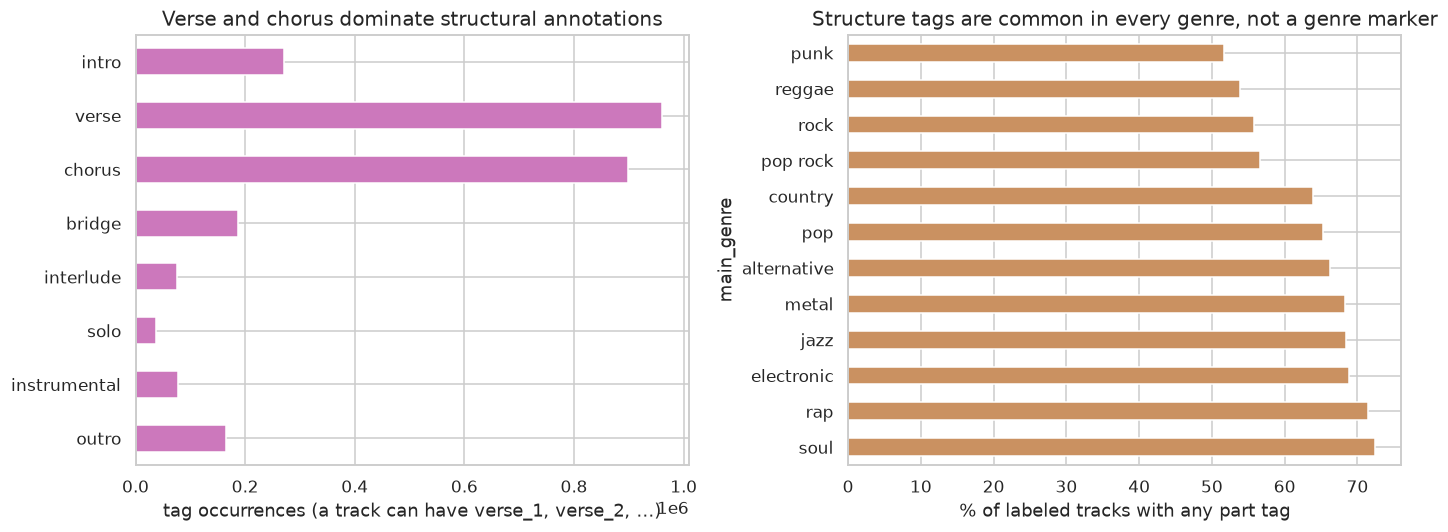

In [20]:
part_series = pd.Series(global_parts).reindex(CANON_PARTS).fillna(0).astype(int)
display(part_series.rename("n_tags").to_frame())

struct_by_genre = (
    lab.groupby("main_genre")["has_structure"].mean().sort_values(ascending=False) * 100
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
part_series.plot(kind="barh", ax=axes[0], color=sns.color_palette("colorblind")[4])
axes[0].invert_yaxis()
axes[0].set_xlabel("tag occurrences (a track can have verse_1, verse_2, …)")
axes[0].set_title("Verse and chorus dominate structural annotations")
struct_by_genre.plot(kind="barh", ax=axes[1], color=sns.color_palette("colorblind")[5])
axes[1].set_xlabel("% of labeled tracks with any part tag")
axes[1].set_title("Structure tags are common in every genre, not a genre marker")
plt.tight_layout()
plt.show()


**What we observed.**

- Length matches the paper’s ballpark (mean ~76, median ~71): enough tokens for sequence models, with a long right tail.
- **Unique chord count** separates genres more than raw length: jazz (and often metal) uses a wider spelling vocabulary; pop and country recycle a small set. That is a cheap feature, but it will not separate pop from rock.
- About **58%** of tracks have part tags (verse/chorus/…). The rest are a flat chord list. Structure is available as an extra signal, not as a required field. Verse/chorus are an order of magnitude more common than solo/interlude.


## 9. Harmonic vocabulary and relationships with genre

We classify each chord token with a **lightweight quality heuristic** (major / minor / seventh-family still counted as major or minor; `sus`, power/`no3`/`5`, dim, aug, half-diminished). Slash chords count as inversions of the triad on the left of `/`.

Then, on **labeled tracks only**, we compare quality mix and 4-gram overlap across `main_genre`. High cosine similarity between pop, rock, alternative, and punk is the reason a chords-only classifier is hard — the paper reports the same pattern.


,n,pct
major,37031152,71.221
minor,13368240,25.711
suspended,731520,1.407
power,730443,1.405
half-diminished,0,0.000
augmented,27627,0.053
diminished,105654,0.203


Inverted (slash) tokens: 1,464,392 (2.82%)


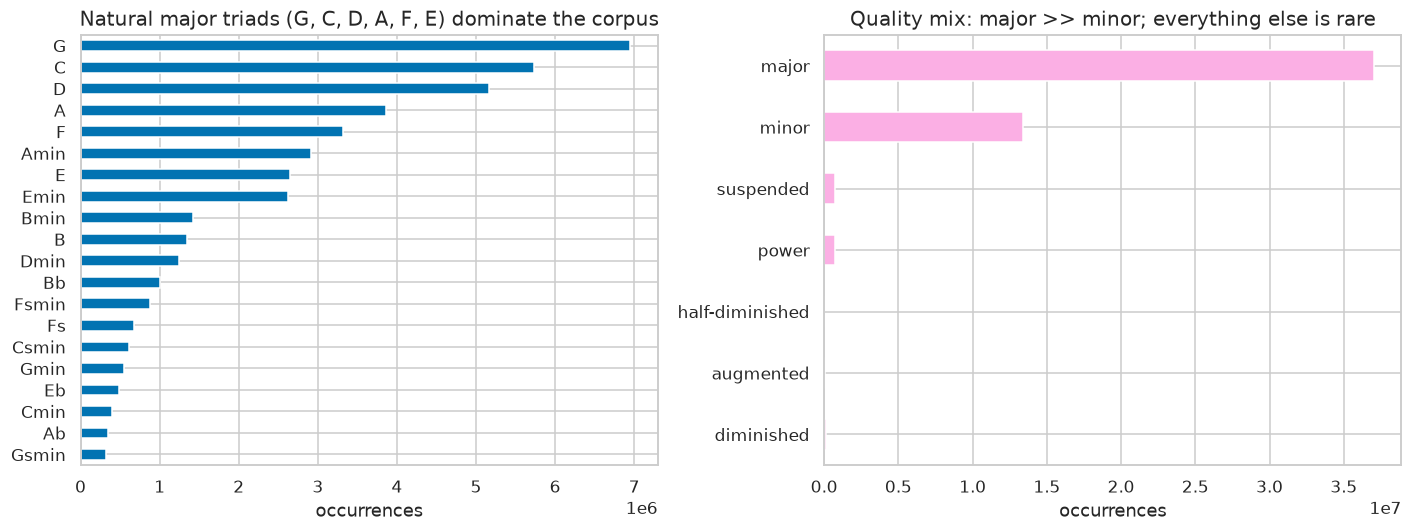

In [21]:
POWER_RE = re.compile(r"^[A-G]s?(?:no3|5)(?:d)?$", re.I)


def chord_quality(token: str) -> str:
    # Heuristic quality. Not Harte-complete; good enough for corpus-level mix.
    core = token.split("/", 1)[0]
    t = core.lower()
    if "sus" in t:
        return "suspended"
    if "aug" in t:
        return "augmented"
    if "hmin" in t or "min7b5" in t:
        return "half-diminished"
    if "dim" in t:
        return "diminished"
    if "no3" in t or POWER_RE.match(core):
        return "power"
    if "min" in t:
        return "minor"
    return "major"


quality_global: Counter[str] = Counter()
n_inversions = 0
for tok, cnt in global_chords.items():
    quality_global[chord_quality(tok)] += cnt
    if "/" in tok:
        n_inversions += cnt

q_order = ["major", "minor", "suspended", "power", "half-diminished", "augmented", "diminished"]
q_series = pd.Series({k: quality_global.get(k, 0) for k in q_order})
q_tbl = q_series.rename("n").to_frame()
q_tbl["pct"] = (100 * q_tbl["n"] / q_tbl["n"].sum()).round(3)
display(q_tbl)
print(f"Inverted (slash) tokens: {n_inversions:,} ({100 * n_inversions / sum(global_chords.values()):.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
top20 = pd.Series(dict(global_chords.most_common(20))).sort_values()
top20.plot(kind="barh", ax=axes[0], color=sns.color_palette("colorblind")[0])
axes[0].set_title("Natural major triads (G, C, D, A, F, E) dominate the corpus")
axes[0].set_xlabel("occurrences")
q_series.plot(kind="barh", ax=axes[1], color=sns.color_palette("colorblind")[6])
axes[1].invert_yaxis()
axes[1].set_title("Quality mix: major >> minor; everything else is rare")
axes[1].set_xlabel("occurrences")
plt.tight_layout()
plt.show()


Genre-conditioned harmonic stats:   0%|          | 0/352111 [00:00<?, ?it/s]

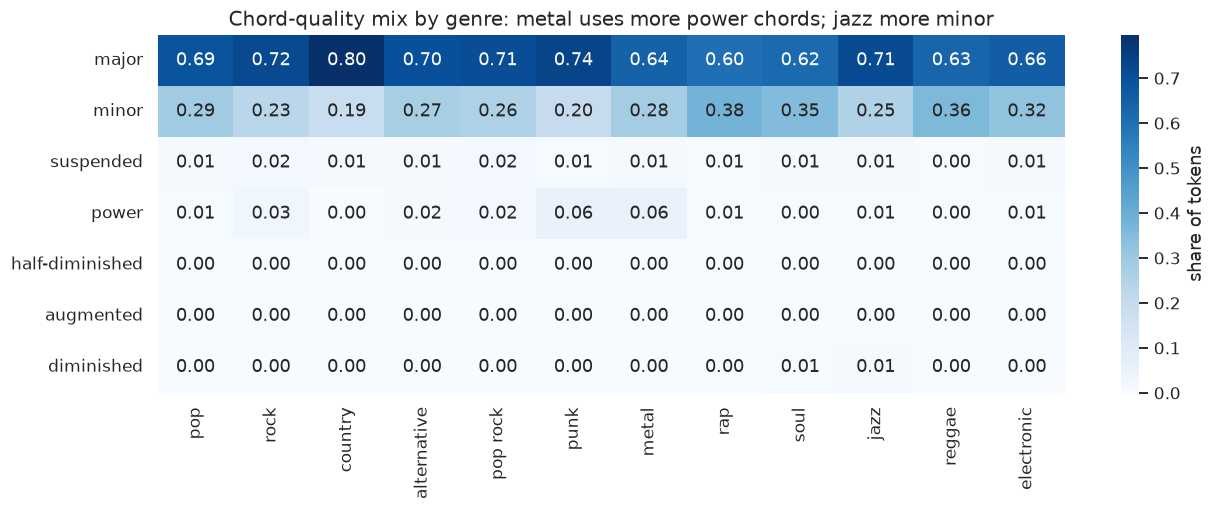

In [22]:
# Second pass over labeled rows only: quality mix + 4-grams per genre.
# Skipping ABAB 4-grams (C G C G) follows the paper's n-gram protocol.
labeled_mask = df["main_genre"].notna().to_numpy()
labeled_chords = df.loc[df["main_genre"].notna(), "chords"].to_numpy()
labeled_genres = df.loc[df["main_genre"].notna(), "main_genre"].to_numpy()

quality_by_genre: dict[str, Counter[str]] = defaultdict(Counter)
quads_by_genre: dict[str, Counter[tuple[str, str, str, str]]] = defaultdict(Counter)
chords_by_genre: dict[str, Counter[str]] = defaultdict(Counter)

for raw, genre in tqdm(zip(labeled_chords, labeled_genres), total=len(labeled_chords),
                       desc="Genre-conditioned harmonic stats"):
    ctoks, _ = split_tokens(raw)
    qg = quality_by_genre[genre]
    cg = chords_by_genre[genre]
    for tok in ctoks:
        qg[chord_quality(tok)] += 1
        cg[tok] += 1
    if len(ctoks) >= 4:
        qg_quad = quads_by_genre[genre]
        for i in range(len(ctoks) - 3):
            a, b, c, d = ctoks[i], ctoks[i + 1], ctoks[i + 2], ctoks[i + 3]
            if a == c and b == d:
                continue
            qg_quad[(a, b, c, d)] += 1

qual_df = (
    pd.DataFrame({g: quality_by_genre[g] for g in genre_counts.index})
    .reindex(q_order)
    .fillna(0)
)
qual_share = qual_df.div(qual_df.sum(axis=0), axis=1)

fig, ax = plt.subplots(figsize=(12, 4.8))
sns.heatmap(qual_share, cmap="Blues", annot=True, fmt=".2f", ax=ax, cbar_kws={"label": "share of tokens"})
ax.set_title("Chord-quality mix by genre: metal uses more power chords; jazz more minor")
plt.tight_layout()
plt.show()


Most common 4-gram (non-ABAB) per main_genre:


,main_genre,top_4gram,n
0,pop,C G Amin F,24628
1,rock,G D C G,13953
2,country,D G C G,22836
3,alternative,F C G F,8943
4,pop rock,G D Emin C,7342
5,punk,C G Amin F,3831
6,metal,Emin C D Emin,2553
7,rap,F C G Amin,3168
8,soul,G D Emin C,681
9,jazz,G D C G,1329


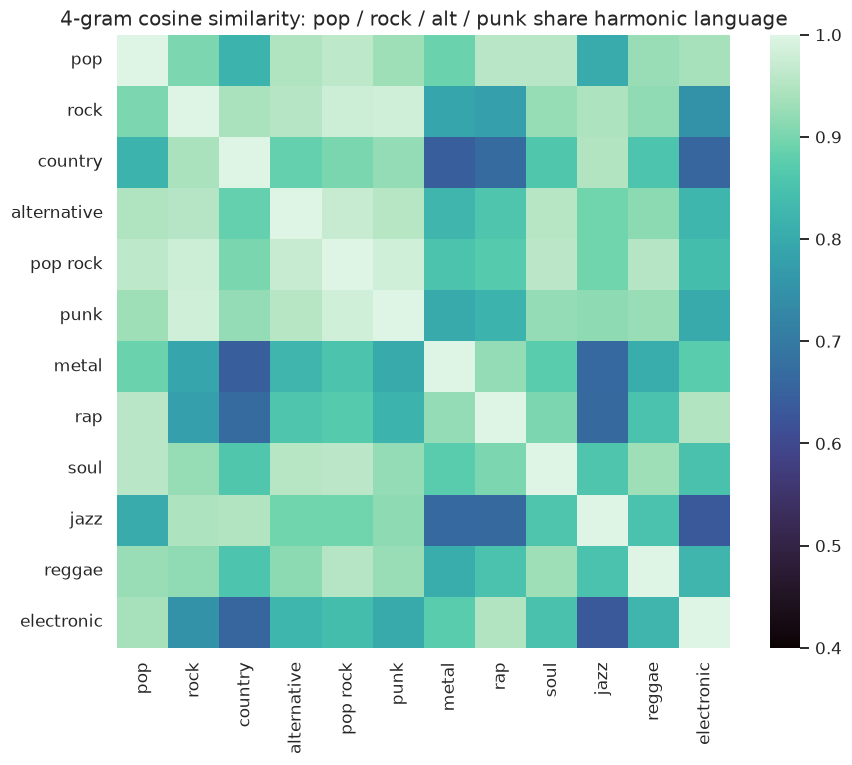

In [23]:
print("Most common 4-gram (non-ABAB) per main_genre:")
rows = []
for g in genre_counts.index:
    if not quads_by_genre[g]:
        continue
    (a, b, c, d), cnt = quads_by_genre[g].most_common(1)[0]
    rows.append({"main_genre": g, "top_4gram": f"{a} {b} {c} {d}", "n": cnt})
display(pd.DataFrame(rows))

# Compact cosine similarity: vocabulary = union of each genre's top 100 4-grams.
vocab: set[tuple[str, str, str, str]] = set()
for g in genre_counts.index:
    vocab.update(q for q, _ in quads_by_genre[g].most_common(100))
vocab_list = sorted(vocab)
idx = {q: i for i, q in enumerate(vocab_list)}

mat = np.zeros((len(genre_counts), len(vocab_list)), dtype=np.float64)
g_list = list(genre_counts.index)
for gi, g in enumerate(g_list):
    for quad, cnt in quads_by_genre[g].items():
        j = idx.get(quad)
        if j is not None:
            mat[gi, j] = cnt
norms = np.linalg.norm(mat, axis=1, keepdims=True)
norms[norms == 0] = 1.0
mat_n = mat / norms
sim = mat_n @ mat_n.T
sim_df = pd.DataFrame(sim, index=g_list, columns=g_list)

fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(sim_df, cmap="mako", vmin=0.4, vmax=1.0, ax=ax, square=True)
ax.set_title("4-gram cosine similarity: pop / rock / alt / punk share harmonic language")
plt.tight_layout()
plt.show()


**What we observed.**

- The vocabulary is **simple-triad heavy**: G, C, D, A, F, E and their relative minors. That matches guitar-capo culture and the fact that UG transcriptions often flatten extensions to triads.
- Quality mix **does** move with genre (power chords in metal, more minor in jazz) but the shift is a change in proportions, not a different alphabet.
- 4-gram cosine similarity is high among pop, rock, pop rock, alternative, and punk. Jazz, electronic, country, and rap sit farther away. A chords-only 12-way model should expect confusion inside that pop/rock cluster; metadata (decade, structure) will not fully break it because those genres also share era and song form.


## 10. Implications for the genre predictor

This section is a design memo, not a model.

**Label universe.** Train on the **352,111** rows with `main_genre`. The other half has no 12-way target. The 77k rows that have Spotify `genres` but no `main_genre` are a possible extra multi-label task, not extra 12-way labels.

**Metric.** Majority baseline is ~24% (pop). Report macro-F1 (or balanced accuracy) in addition to accuracy, or the model will ignore jazz / reggae / electronic.

**Split.** `main_genre` is an artist attribute. Split by `artist_id`, and put tracks with missing `artist_id` in their own bucket (or drop them from the supervised set). A random row split will leak.

**Features that looked informative here.**

- Unique-chord count and quality mix (power vs minor vs major)
- 4-gram / sequence models for the distant pairs (jazz vs electronic, country vs rap)
- Optional part tags as extra tokens (`<chorus>`, `<bridge>`) — they improved next-chord prediction in the paper; for genre they are weakly informative alone

**Features that will not save the pop/rock cluster.** Decade (everything is recent pop/rock), raw most-common chords (G/C/D everywhere), and `rock_genre` (different task, 179-way, missing on most rows).

**Do not assume `decade == f(release_date)`.** If time is used as a feature, pick one field and document it.

**Duplicates.** Exact duplicate progressions are rare; artist-grouped splits already limit the damage.

No CSV was modified. All extra columns (`n_chords`, `has_structure`, …) exist only in this notebook session.


In [24]:
print("=== Supervised 12-way snapshot ===")
print(f"All tracks:              {len(df):>9,}")
print(f"With main_genre:         {int(df['main_genre'].notna().sum()):>9,}")
print(f"With artist_id + label:  {int((df['main_genre'].notna() & df['artist_id'].notna()).sum()):>9,}")
print(f"With structure tags:     {int(df['has_structure'].sum()):>9,}")
print(f"main_genre classes:      {df['main_genre'].nunique():>9}")
print("class sizes:", df["main_genre"].value_counts().to_dict())


=== Supervised 12-way snapshot ===
All tracks:                679,807
With main_genre:           352,111
With artist_id + label:    352,111
With structure tags:       397,580
main_genre classes:             12
class sizes: {'pop': 85185, 'rock': 67238, 'country': 53306, 'alternative': 47252, 'pop rock': 39557, 'punk': 16066, 'metal': 11315, 'rap': 11186, 'soul': 7350, 'jazz': 7001, 'reggae': 3841, 'electronic': 2814}
